In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x) # Step sizes between data points
    # Initialize the tridiagonal matrix coefficients
    A = np.zeros(n - 2) # Subdiagonal
    B = np.zeros(n - 2) # Main diagonal
    C = np.zeros(n - 2) # Superdiagonal
    D = np.zeros(n - 2) # Right-hand side vector
    # Populate the tridiagonal matrix coefficients
    for i in range(1, n - 1):
        A[i - 1] = h[i - 1] # Subdiagonal
        B[i - 1] = 2 * (h[i-1] + h[i]) # Main diagonal
        C[i - 1] = h[i] # Superdiagonal
        D[i - 1] = 6 * ((y[i+1]-y[i])/h[i] - (y[i]-y[i-1])/h[i-1]) # Right-hand side vector
    return A, B, C, D

In [3]:
def thomas_algorithm(a, b, c, d):
    """
    Solve the tridiagonal system using the Thomas algorithm.
    a: sub-diagonal elements (length n-1)
    b: main diagonal elements (length n)
    c: super-diagonal elements (length n-1)
    d: right-hand side (length n)
    Returns: solution vector x of length n
    """
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

In [4]:
def evaluate_spline(x_data, y_data, M, x_query):
    """M: second derivatives; M[0]=M[-1]=0 for natural spline"""
    n = len(x_data)
    h = np.diff(x_data) # step sizes
    
    i = np.searchsorted(x_data, x_query, side='right') - 1
    i = np.clip(i, 0, n - 2) # find interval
    
    hi = h[i]
    dx_left = x_query - x_data[i] # (x - xᵢ)
    dx_right = x_data[i+1] - x_query # (xᵢ₊₁ - x)
    
    S = (
        (M[i] / (6*hi)) * dx_right**3 + # Term 1
        (M[i+1] / (6*hi)) * dx_left**3 + # Term 2
        (y_data[i] /hi - M[i] *hi/6) * dx_right + # Term 3
        (y_data[i+1] /hi - M[i+1] *hi/6) * dx_left # Term 4
    )
    return S

In [13]:
x = np.array([0.0, 1.0, 4.0, 5.0, 7.0, 8.0])
y = np.array([0.0, 0.1, 1.0, 5.5, 0.2, 0.0])

A, B, C, D = setup_tridiagonal_matrix(x, y)

M_interior = thomas_algorithm(A, B, C, D)

M = np.concatenate(([0.0], M_interior, [0.0]))
 
print("Second derivatives M:", np.round(M, 6))

x_eval = np.arange(x[0], x[-1] + 0.01, 0.01)   # x₀ → xₙ in steps of 0.01

y_eval = []
for xi in x_eval:
    yi = evaluate_spline(x, y, M, xi)
    y_eval.append(yi)

y_eval = np.array(y_eval)

Second derivatives M: [  0.        -1.619689   4.719171 -10.933679   4.27228    0.      ]


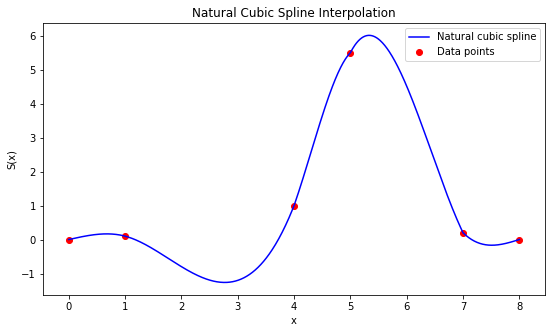

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
 
ax.plot(x_eval, y_eval, color='blue', label='Natural cubic spline')
ax.scatter(x, y, color='red', label='Data points')
 
ax.set_title('Natural Cubic Spline Interpolation')
ax.set_xlabel('x')
ax.set_ylabel('S(x)')
ax.legend()
plt.show()